# 05 - Avaliacao Comparativa Final + Insumos para o Docx e para os Slides

Objetivo: consolidar os resultados das Trilhas A (Notebook 03) e B (Notebook 04), compara-los com a literatura (Secao 3 do plano), responder ao **Objetivo Especifico 2** (binario Engajado vs. Desengajado) e produzir as tabelas/figuras finais que vao direto para:

- `mini-qualificacao/INF-009 2026.2 - Template Mini-qualificacao.docx` (Secao 11 do plano)
- Apresentacao de 8 slides (Secao 12 do plano)

Este notebook tambem aplica o **criterio de validacao da hipotese** definido na Secao 10 do plano (corroborada / parcialmente corroborada / nao corroborada).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score, cohen_kappa_score, accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

ROOT = Path.cwd().parent
FEATURES_DIR = ROOT / "datasets" / "DAiSEE" / "features"

## 1. Consolidar resultados das Trilhas A e B

In [2]:
trilha_a = pd.read_csv(FEATURES_DIR / "resultados_trilha_a_classico.csv")
trilha_b = pd.read_csv(FEATURES_DIR / "resultados_trilha_b_dl.csv")

consolidado = pd.concat([trilha_a, trilha_b], ignore_index=True)
consolidado = consolidado.sort_values("macro_f1", ascending=False)
consolidado

,modelo,acc,macro_f1,kappa,balanced_acc
2,RandomForest (class_weight=balanced),0.526862,0.382358,0.110779,0.384354
4,XGBoost (sample_weight balanceado),0.482906,0.345600,0.051708,0.369890
3,RandomForest + SMOTE,0.491453,0.282137,0.079222,0.289169
7,BiLSTM ordinal (CORAL),0.523810,0.265777,0.060611,NaN
1,RandomForest (sem balanceamento),0.515263,0.246566,0.040728,0.261203
5,SVM (class_weight=balanced),0.362027,0.208052,0.034359,0.244939
0,Baseline trivial (classe majoritaria),0.518315,0.170688,0.000000,0.250000
6,BiLSTM + Focal Loss (class-weighted),0.156899,0.121010,0.032612,NaN


## 2. Tabela comparativa com a literatura 2024+ (Secao 3 do plano)

Preencher `nosso_resultado_macro_f1`/`nosso_resultado_acc` com os valores do melhor modelo obtido acima.

In [3]:
literatura = pd.DataFrame([
    {"referencia": "Gupta et al. 2016 - LRCN, benchmark original DAiSEE (arXiv:1609.01885)", "acc": 0.579, "reporta_macro_f1_kappa": False},
    {"referencia": "Liao et al. 2021 - DFSTN (DOI:10.1007/s10489-020-02139-8)", "acc": 0.5884, "reporta_macro_f1_kappa": False},
    {"referencia": "Abedi & Khan 2021 (ordinal, arXiv:2106.10882)", "acc": 0.674, "reporta_macro_f1_kappa": False},
    {"referencia": "Mehta et al. 2022 - 3D DenseAttNet (DOI:10.1007/s10489-022-03200-4)", "acc": 0.6359, "reporta_macro_f1_kappa": False},
    {"referencia": "Bag of States 2023 (arXiv:2301.06730)", "acc": 0.6658, "reporta_macro_f1_kappa": False},
    {"referencia": "Sugihdharma & Bachtiar 2023 - SAE-CNN, so eye/gaze (DOI:10.1145/3626641.3626938)", "acc": 0.9581, "reporta_macro_f1_kappa": False},
    {"referencia": "Malekshahi et al. 2024 (arXiv:2405.04251)", "acc": 0.6857, "reporta_macro_f1_kappa": False},
    {"referencia": "Shiri et al. 2024 - ConvNeXtLarge+Bi-GRU (DOI:10.1109/ICIET60671.2024.10542707)", "acc": 0.7018, "reporta_macro_f1_kappa": False},
    {"referencia": "VisioPhysioENet 2024 (arXiv:2409.16126)", "acc": 0.6309, "reporta_macro_f1_kappa": False},
    {"referencia": "EngageFormer 2025 (arXiv:2502.10813)", "acc": 0.639, "reporta_macro_f1_kappa": False},
    {"referencia": "ViBED-Net 2025 (arXiv:2510.18016)", "acc": 0.7343, "reporta_macro_f1_kappa": False},
])
# NOTA (Secao 3 do plano): o valor do SAE-CNN (95,81%) esta muito acima do restante da literatura
# (~58-73%) e seu protocolo de avaliacao (classes/split, ausencia de macro-F1/kappa) precisa ser
# checado antes de ser usado como cota superior realista - tratar com o mesmo ceticismo metodologico
# aplicado ao caso MobileNetV2 (arXiv:2601.08049) discutido na Secao 3.

melhor_modelo = consolidado.iloc[0]
nosso_resultado = pd.DataFrame([{
    "referencia": f"NOSSO PoC - {melhor_modelo['modelo']}",
    "acc": melhor_modelo["acc"],
    "reporta_macro_f1_kappa": True,
}])

comparativo_final = pd.concat([literatura, nosso_resultado], ignore_index=True).sort_values("acc", ascending=False)
comparativo_final

,referencia,acc,reporta_macro_f1_kappa
5,"Sugihdharma & Bachtiar 2023 - SAE-CNN, so eye/...",0.958100,False
10,ViBED-Net 2025 (arXiv:2510.18016),0.734300,False
7,Shiri et al. 2024 - ConvNeXtLarge+Bi-GRU (DOI:...,0.701800,False
6,Malekshahi et al. 2024 (arXiv:2405.04251),0.685700,False
2,"Abedi & Khan 2021 (ordinal, arXiv:2106.10882)",0.674000,False
4,Bag of States 2023 (arXiv:2301.06730),0.665800,False
9,EngageFormer 2025 (arXiv:2502.10813),0.639000,False
3,Mehta et al. 2022 - 3D DenseAttNet (DOI:10.100...,0.635900,False
8,VisioPhysioENet 2024 (arXiv:2409.16126),0.630900,False
1,Liao et al. 2021 - DFSTN (DOI:10.1007/s10489-0...,0.588400,False


## 3. Bootstrap CI (macro-F1 e kappa) do melhor modelo vs. baseline trivial

Ver criterio de "corroboracao da hipotese" na Secao 10 do plano: IC 95% nao deve se sobrepor ao do baseline trivial.

In [4]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=1000, **kwargs):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        scores.append(metric_fn(y_true[idx], y_pred[idx], **kwargs))
    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5), scores.mean()

# Carrega predicoes reais persistidas pelos Notebooks 03 e 04
pred_a = pd.read_csv(FEATURES_DIR / "predicoes_teste_trilha_a.csv")
pred_b = pd.read_csv(FEATURES_DIR / "predicoes_teste_trilha_b.csv")
pred_base = pd.read_csv(FEATURES_DIR / "predicoes_teste_baseline.csv")

# Escolhe a trilha vencedora por macro-F1 no teste
f1_a = f1_score(pred_a["y_true"], pred_a["y_pred"], average="macro")
f1_b = f1_score(pred_b["y_true"], pred_b["y_pred"], average="macro")
usa_a = f1_a >= f1_b
melhor_pred = pred_a if usa_a else pred_b
melhor_label = "Trilha A (ML classico)" if usa_a else "Trilha B (BiLSTM)"
print(f"Macro-F1 Trilha A={f1_a:.4f} | Trilha B={f1_b:.4f} -> melhor: {melhor_label}")

boot_rows = []
for nome, dfp in [(melhor_label, melhor_pred), ("Baseline trivial", pred_base)]:
    lo_f1, hi_f1, m_f1 = bootstrap_metric(dfp["y_true"], dfp["y_pred"], f1_score, average="macro")
    lo_k, hi_k, m_k = bootstrap_metric(dfp["y_true"], dfp["y_pred"], cohen_kappa_score)
    boot_rows.append({
        "modelo": nome,
        "macro_f1_media": m_f1, "macro_f1_ic_low": lo_f1, "macro_f1_ic_high": hi_f1,
        "kappa_media": m_k, "kappa_ic_low": lo_k, "kappa_ic_high": hi_k,
    })
    print(f"{nome}: macro-F1={m_f1:.3f} IC95%=[{lo_f1:.3f},{hi_f1:.3f}] | kappa={m_k:.3f} IC95%=[{lo_k:.3f},{hi_k:.3f}]")

boot_df = pd.DataFrame(boot_rows)

# Teste de sobreposicao de IC (criterio da Secao 10 do plano)
sobrepoe_f1 = boot_df.loc[0, "macro_f1_ic_low"] <= boot_df.loc[1, "macro_f1_ic_high"]
sobrepoe_kappa = boot_df.loc[0, "kappa_ic_low"] <= boot_df.loc[1, "kappa_ic_high"]
print(f"\nIC95% macro-F1 se sobrepoe ao baseline? {'SIM' if sobrepoe_f1 else 'NAO'}")
print(f"IC95% kappa se sobrepoe ao baseline?    {'SIM' if sobrepoe_kappa else 'NAO'}")
boot_df

Macro-F1 Trilha A=0.3824 | Trilha B=0.1210 -> melhor: Trilha A (ML classico)


Trilha A (ML classico): macro-F1=0.378 IC95%=[0.307,0.481] | kappa=0.110 IC95%=[0.068,0.152]


Baseline trivial: macro-F1=0.172 IC95%=[0.166,0.177] | kappa=0.000 IC95%=[0.000,0.000]

IC95% macro-F1 se sobrepoe ao baseline? NAO
IC95% kappa se sobrepoe ao baseline?    NAO


,modelo,macro_f1_media,macro_f1_ic_low,macro_f1_ic_high,kappa_media,kappa_ic_low,kappa_ic_high
0,Trilha A (ML classico),0.377772,0.307093,0.481144,0.109761,0.06755,0.151787
1,Baseline trivial,0.171620,0.165574,0.177432,0.000000,0.00000,0.000000


## 4. Objetivo Especifico 2 - Engajado vs. Desengajado (binario)

Reformular Engagement {0,1} -> Desengajado (0) e {2,3} -> Engajado (1). Meta: recall(Desengajado) >= 60% e AUC-ROC >= 0.70 (Secao 2 do plano).

Distribuicao binaria no teste: Desengajado=85 | Engajado=1553
Recall(Desengajado) = 0.259  (meta >= 0.60)
Recall(Engajado)    = 0.971
AUC-ROC             = 0.731  (meta >= 0.70)
Matriz de confusao binaria [linhas=real 0/1, colunas=predito 0/1]:
[[  22   63]
 [  45 1508]]


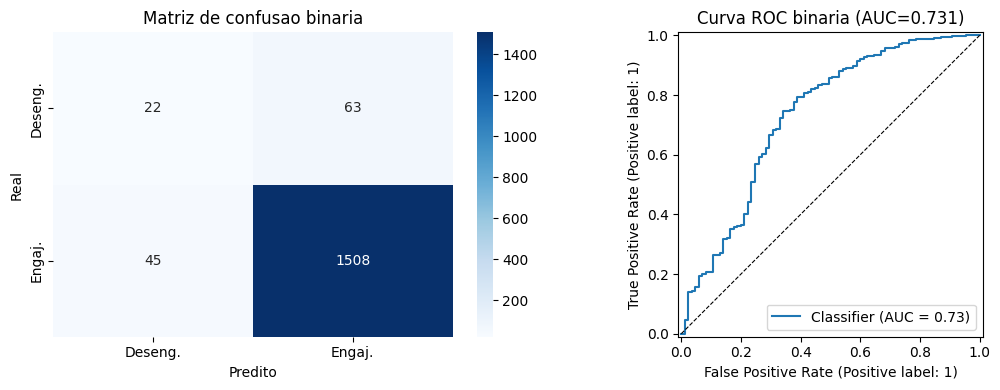

,recall_desengajado,recall_engajado,auc_roc,meta_recall_atingida,meta_auc_atingida
0,0.258824,0.971024,0.730578,False,True


In [5]:
def to_binary_engagement(y):
    return (np.array(y) >= 2).astype(int)  # 1 = Engajado, 0 = Desengajado

y_test_bin = to_binary_engagement(melhor_pred["y_true"])
y_pred_bin = to_binary_engagement(melhor_pred["y_pred"])

proba_cols = sorted([c for c in melhor_pred.columns if c.startswith("proba_")])
# P(Engajado) = P(classe 2) + P(classe 3)
proba_engajado = melhor_pred[[c for c in proba_cols if c.split("_")[1] in ("2", "3")]].sum(axis=1).values

recall_deseng = recall_score(y_test_bin, y_pred_bin, pos_label=0)
recall_eng = recall_score(y_test_bin, y_pred_bin, pos_label=1)
auc = roc_auc_score(y_test_bin, proba_engajado)
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

print(f"Distribuicao binaria no teste: Desengajado={int((y_test_bin==0).sum())} | Engajado={int((y_test_bin==1).sum())}")
print(f"Recall(Desengajado) = {recall_deseng:.3f}  (meta >= 0.60)")
print(f"Recall(Engajado)    = {recall_eng:.3f}")
print(f"AUC-ROC             = {auc:.3f}  (meta >= 0.70)")
print("Matriz de confusao binaria [linhas=real 0/1, colunas=predito 0/1]:")
print(cm_bin)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Deseng.", "Engaj."], yticklabels=["Deseng.", "Engaj."])
axes[0].set_title("Matriz de confusao binaria")
axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
RocCurveDisplay.from_predictions(y_test_bin, proba_engajado, ax=axes[1])
axes[1].set_title(f"Curva ROC binaria (AUC={auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
fig.tight_layout()
plt.show()

binario = pd.DataFrame([{
    "recall_desengajado": recall_deseng, "recall_engajado": recall_eng,
    "auc_roc": auc,
    "meta_recall_atingida": bool(recall_deseng >= 0.60),
    "meta_auc_atingida": bool(auc >= 0.70),
}])
binario

## 5. Ablacoes (balanceamento e ordinalidade) - resumo

Preencher com os resultados reais das estrategias testadas nos Notebooks 03 e 04.

In [6]:
ablacoes = consolidado[["modelo", "acc", "macro_f1", "kappa"]].copy()
ablacoes["delta_macro_f1_vs_baseline"] = ablacoes["macro_f1"] - ablacoes.loc[ablacoes["modelo"].str.contains("trivial"), "macro_f1"].values[0]
ablacoes.sort_values("macro_f1", ascending=False)

,modelo,acc,macro_f1,kappa,delta_macro_f1_vs_baseline
2,RandomForest (class_weight=balanced),0.526862,0.382358,0.110779,0.211670
4,XGBoost (sample_weight balanceado),0.482906,0.345600,0.051708,0.174913
3,RandomForest + SMOTE,0.491453,0.282137,0.079222,0.111449
7,BiLSTM ordinal (CORAL),0.523810,0.265777,0.060611,0.095090
1,RandomForest (sem balanceamento),0.515263,0.246566,0.040728,0.075878
5,SVM (class_weight=balanced),0.362027,0.208052,0.034359,0.037365
0,Baseline trivial (classe majoritaria),0.518315,0.170688,0.000000,0.000000
6,BiLSTM + Focal Loss (class-weighted),0.156899,0.121010,0.032612,-0.049678


## 6. Decisao final sobre a hipotese (Secao 10 do plano)

Preencher manualmente apos rodar as celulas acima:

- Macro-F1 do melhor modelo: `____`
- Kappa do melhor modelo: `____`
- IC 95% se sobrepoe ao baseline trivial? `sim/nao`
- Recall(Desengajado) binario: `____` (meta >= 60%)
- AUC-ROC binario: `____` (meta >= 0.70)
- **Conclusao:** [ ] Corroborada  [ ] Parcialmente corroborada  [ ] Nao corroborada
- Justificativa (2-3 frases, para usar direto no Resumo/Discussao do docx e no slide 7):

In [7]:
# Aplicacao automatica do criterio da Secao 10 do plano
ganho_significativo = (not sobrepoe_f1) and (not sobrepoe_kappa)
meta_recall = bool(recall_deseng >= 0.60)
meta_auc = bool(auc >= 0.70)

if ganho_significativo and meta_recall:
    veredito = "CORROBORADA"
elif ganho_significativo:
    veredito = "PARCIALMENTE CORROBORADA"
else:
    veredito = "NAO CORROBORADA"

m_f1 = boot_df.loc[0, "macro_f1_media"]; m_k = boot_df.loc[0, "kappa_media"]
b_f1 = boot_df.loc[0, "macro_f1_ic_low"], boot_df.loc[0, "macro_f1_ic_high"]
b_k = boot_df.loc[0, "kappa_ic_low"], boot_df.loc[0, "kappa_ic_high"]

print("=" * 70)
print(f"MELHOR MODELO ............. {melhor_label}")
print(f"Macro-F1 .................. {m_f1:.3f}  IC95% [{b_f1[0]:.3f}, {b_f1[1]:.3f}]")
print(f"Kappa ..................... {m_k:.3f}  IC95% [{b_k[0]:.3f}, {b_k[1]:.3f}]")
print(f"IC se sobrepoe ao baseline? macro-F1={'SIM' if sobrepoe_f1 else 'NAO'} | kappa={'SIM' if sobrepoe_kappa else 'NAO'}")
print(f"Recall(Desengajado) ....... {recall_deseng:.3f}  (meta >=0.60: {'OK' if meta_recall else 'NAO ATINGIDA'})")
print(f"AUC-ROC ................... {auc:.3f}  (meta >=0.70: {'OK' if meta_auc else 'NAO ATINGIDA'})")
print(f"\n>>> HIPOTESE: {veredito}")
print("=" * 70)

decisao = pd.DataFrame([{
    "melhor_modelo": melhor_label,
    "macro_f1": m_f1, "macro_f1_ic": f"[{b_f1[0]:.3f}, {b_f1[1]:.3f}]",
    "kappa": m_k, "kappa_ic": f"[{b_k[0]:.3f}, {b_k[1]:.3f}]",
    "recall_desengajado": recall_deseng, "auc_roc": auc,
    "veredito_hipotese": veredito,
}])
decisao

MELHOR MODELO ............. Trilha A (ML classico)
Macro-F1 .................. 0.378  IC95% [0.307, 0.481]
Kappa ..................... 0.110  IC95% [0.068, 0.152]
IC se sobrepoe ao baseline? macro-F1=NAO | kappa=NAO
Recall(Desengajado) ....... 0.259  (meta >=0.60: NAO ATINGIDA)
AUC-ROC ................... 0.731  (meta >=0.70: OK)

>>> HIPOTESE: PARCIALMENTE CORROBORADA


,melhor_modelo,macro_f1,macro_f1_ic,kappa,kappa_ic,recall_desengajado,auc_roc,veredito_hipotese
0,Trilha A (ML classico),0.377772,"[0.307, 0.481]",0.109761,"[0.068, 0.152]",0.258824,0.730578,PARCIALMENTE CORROBORADA


## 7. Exportar tabelas/figuras finais para uso no docx e nos slides

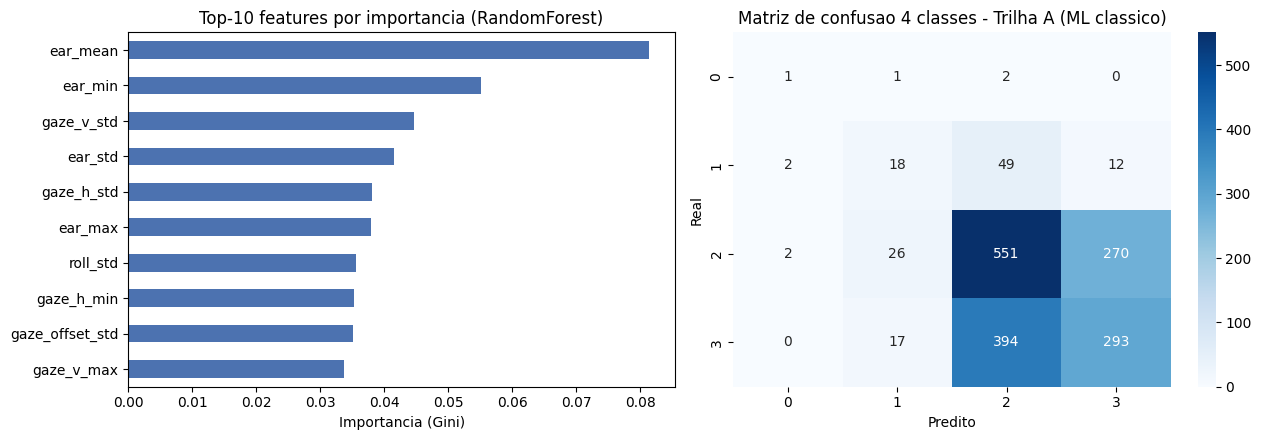

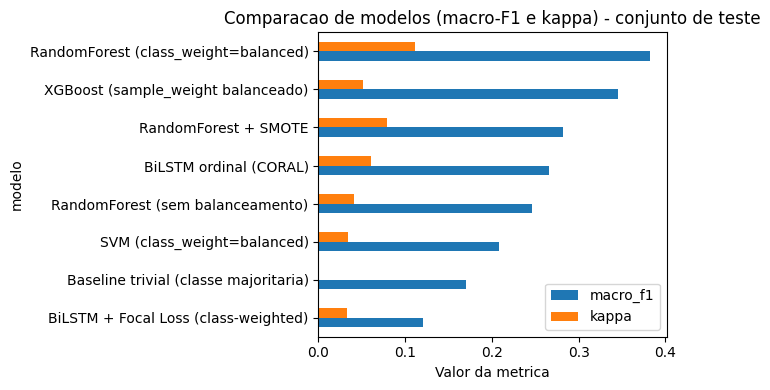

Arquivos exportados em: C:\Users\paulo\Documents\Mestrado\Projetos de Pesquisa\Engajamento_EAD\mini-qualificacao\insumos_gerados
  - decisao_hipotese.csv
  - fig_comparacao_modelos.png
  - fig_importancia_e_confusao.png
  - tabela_ablacoes.csv
  - tabela_bootstrap_ic95.csv
  - tabela_comparativa_literatura.csv
  - tabela_estabilidade_features.csv
  - tabela_importancia_features.csv
  - tabela_objetivo2_binario.csv
  - tabela_resultados_consolidados.csv


In [8]:
OUTPUT_DIR = ROOT / "mini-qualificacao" / "insumos_gerados"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

consolidado.to_csv(OUTPUT_DIR / "tabela_resultados_consolidados.csv", index=False)
comparativo_final.to_csv(OUTPUT_DIR / "tabela_comparativa_literatura.csv", index=False)
ablacoes.to_csv(OUTPUT_DIR / "tabela_ablacoes.csv", index=False)
boot_df.to_csv(OUTPUT_DIR / "tabela_bootstrap_ic95.csv", index=False)
binario.to_csv(OUTPUT_DIR / "tabela_objetivo2_binario.csv", index=False)
decisao.to_csv(OUTPUT_DIR / "decisao_hipotese.csv", index=False)

# Importancia de features (Objetivo Especifico 1), vinda do Notebook 03
imp = pd.read_csv(FEATURES_DIR / "importancias_features_engagement.csv", index_col=0)
est = pd.read_csv(FEATURES_DIR / "estabilidade_top5_features.csv", index_col=0)
imp.to_csv(OUTPUT_DIR / "tabela_importancia_features.csv")
est.to_csv(OUTPUT_DIR / "tabela_estabilidade_features.csv")

# --- Figuras finais para o docx e os slides ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

imp.head(10).iloc[::-1].plot(kind="barh", ax=axes[0], legend=False, color="#4C72B0")
axes[0].set_title("Top-10 features por importancia (RandomForest)")
axes[0].set_xlabel("Importancia (Gini)")

cm_final = confusion_matrix(melhor_pred["y_true"], melhor_pred["y_pred"])
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["0", "1", "2", "3"], yticklabels=["0", "1", "2", "3"])
axes[1].set_title(f"Matriz de confusao 4 classes - {melhor_label}")
axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_importancia_e_confusao.png", dpi=200, bbox_inches="tight")
plt.show()

fig2, ax = plt.subplots(figsize=(7, 4))
plot_df = consolidado.set_index("modelo")[["macro_f1", "kappa"]].sort_values("macro_f1")
plot_df.plot(kind="barh", ax=ax)
ax.set_title("Comparacao de modelos (macro-F1 e kappa) - conjunto de teste")
ax.set_xlabel("Valor da metrica")
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "fig_comparacao_modelos.png", dpi=200, bbox_inches="tight")
plt.show()

print("Arquivos exportados em:", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print("  -", f.name)

## Checklist de saida
- [ ] Tabela consolidada Trilha A vs. B gerada
- [ ] Tabela comparativa com a literatura preenchida com os resultados reais
- [ ] Bootstrap CI calculado para o melhor modelo vs. baseline trivial
- [ ] Versao binaria (Objetivo Especifico 2) avaliada (recall + AUC-ROC)
- [ ] Tabela de ablacoes preenchida
- [ ] Decisao sobre a hipotese registrada (Secao 10 do plano) com justificativa
- [ ] Tabelas exportadas para `mini-qualificacao/insumos_gerados/`

Com isso, todos os insumos necessarios para o docx (5 paginas) e para os 8 slides estao prontos (ver Secoes 11 e 12 do plano `PLANO_EXECUCAO_MINIQUALIFICACAO.md`).